# Principal Component Analysis of Water Treatment Plant Data

**Author:** Anthony Mitine <br>
**Course:** MATH 182. Hidden Data in Random Matrices <br>
**Date:** March 13, 2026

**Dataset:** The dataset for the project is the Water Treatment Plant Dataset [https://archive.ics.uci.edu/dataset/106/water+treatment+plant] from the UCI Machine Learning Repository [http://archive.ics.uci.edu/ml]. The dataset has 527 samples and 38 features, therefore, its aspect ratio is 0.072.<br>
**Dataset Citation:** Poch, Manel. "Water Treatment Plant." UCI Machine Learning Repository, 1993, https://doi.org/10.24432/C5FS4C.

## Overview
This notebook executes a high-dimensional data analysis on the Water Treatment Plant dataset. The objective is to compute the eigenvalues of the sample covariance matrix, fit the Marčenko-Pastur density to find the empirical noise edge, and project the data onto principal coordinates to analyze outliers

In [1]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Used for reading dataset
import urllib.request

# Used for 3D Projection 
from mpl_toolkits.mplot3d import Axes3D

## Pick a dataset and check the Aspect Ratio
From the UCI ML Repository, I used the Water Treatment Plant Dataset, which contains the daily sensor measurements from the urban wastewater facility. After handling missing values by replacing them with column means, I center and standardize the data.

To ensure the use of an appropriately large dataset, I verified that the aspect ratio $\gamma = \frac{m}{n}$ (where $m$ is the number of features and $n$ is the number of samples) of the dataset strictly falls between 0.05 ($1/20$) and 20.

In [2]:
# Load the dataset directly from UCI repository
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/water-treatment/water-treatment.data"
df = pd.read_csv(url, header=None, na_values='?')

# Drop the first column to only have numerical features
df = df.drop(columns=[0])

# Impute missing values with the mean of each column to preserve sample size
df = df.fillna(df.mean())

# Extract values
X_raw = df.values
n, m = X_raw.shape

# Standardize the data 
X_centered = X_raw - np.mean(X_raw, axis=0)
X = X_centered / np.std(X_centered, axis=0)

# Calculate aspect ratio
gamma = m / n

print(f"Number of samples (n): {n}")
print(f"Number of features (m): {m}")
print(f"Aspect Ratio (gamma): {gamma:.3f}")

# Verify the aspect ratio is within the required bounds
if 0.05 <= gamma <= 20:
    print("Aspect ratio is within the acceptable range [1/20, 20].")
else:
    print("Warning: Aspect ratio is outside the acceptable range.")

Number of samples (n): 527
Number of features (m): 38
Aspect Ratio (gamma): 0.072
Aspect ratio is within the acceptable range [1/20, 20].


As shown in the output above, the aspect ratio $\gamma = \frac{m}{n}$ is 0.072. This falls within the acceptable range of 0.05 to 20, confirming that the dataset is appropriately large and high-dimensional for this analysis.

## Compute Eigenvalues and Plot Histogram
To isolate the true structural signals in the dataset from random noise, I calculated the sample covariance matrix $C = \frac{1}{n} X^T X$ using the standardized data and extracted its eigenvalues. The eigenvalues were then sorted in descending order to prepare for the extraction of principal components. 

Next, I plotted a histogram of these empirical eigenvalues alongside the theoretical Marčenko-Pastur (MP) density distribution. The MP density defines the expected distribution of eigenvalues for a purely random matrix with the same aspect ratio $\gamma$. By calculating the upper bound of this distribution, the noise edge $\lambda_+ = (1 + \sqrt{\gamma})^2$, we establish a clear mathematical threshold for statistical significance.

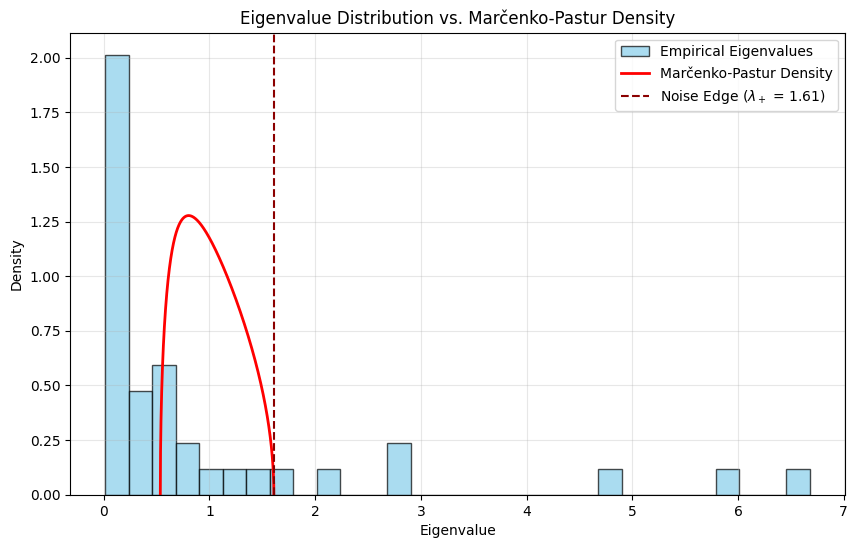

In [3]:
# Compute the sample covariance matrix
C = (1 / n) * (X.T @ X)

# Calculate eigenvalues
eigenvalues, eigenvectors = np.linalg.eigh(C)

# Sort eigenvalues in descending order for easier analysis later
sorted_indices = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[sorted_indices]
eigenvectors = eigenvectors[:, sorted_indices]

# Define Marcenko-Pastur bounds
lambda_plus = (1 + np.sqrt(gamma))**2
lambda_minus = (1 - np.sqrt(gamma))**2

# Function to compute Marcenko-Pastur density
def marcenko_pastur_density(x, gamma):
    valid_x = np.where((x >= lambda_minus) & (x <= lambda_plus), x, np.nan)
    density = np.sqrt((lambda_plus - valid_x) * (valid_x - lambda_minus)) / (2 * np.pi * gamma * valid_x)
    return np.nan_to_num(density) # replace NaNs with 0

# Plotting the histogram of empirical eigenvalues
plt.figure(figsize=(10, 6))
plt.hist(eigenvalues, bins=30, density=True, alpha=0.7, color='skyblue', edgecolor='black', label='Empirical Eigenvalues')

# Plotting the theoretical Marcenko-Pastur density
x_val = np.linspace(lambda_minus, lambda_plus, 1000)
y_val = marcenko_pastur_density(x_val, gamma)
plt.plot(x_val, y_val, color='red', linewidth=2, label='Marčenko-Pastur Density')

# Marking the noise edge
plt.axvline(x=lambda_plus, color='darkred', linestyle='--', label=f'Noise Edge ($\lambda_+$ = {lambda_plus:.2f})')

plt.title("Eigenvalue Distribution vs. Marčenko-Pastur Density")
plt.xlabel("Eigenvalue")
plt.ylabel("Density")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### Histogram Analysis
The resulting plot delineates the random noise from the meaningful structural variance within the dataset. The theoretical Marčenko-Pastur density, shown by the red curve, bounds the expected random noise and ends at the calculated noise edge of $\lambda_+ = 1.61$. 

While a large portion of the empirical eigenvalues fall below this threshold, there is a distinct set of eigenvalues extending far to the right of the dashed line. Since these values strictly exceed the MP upper bound, they represent statistically significant outliers. These are the dominant signals that capture the true underlying variances in the water treatment plant's operations.

## Identify Outliers
Following the analysis from the histogram, the next step is to mathematically determine which eigenvalues fall outside the predicted Marčenko-Pastur density. Any empirical eigenvalue strictly greater than the calculated upper noise edge ($\lambda_+ = 1.61$) is classified as an outlier. These outliers correspond to the true, statistically significant structural signals within the dataset.

By isolating these specific eigenvalues, I quantified how many significant principal components exist and prepared to extract them for dimensionality reduction.

In [4]:
# Identify eigenvalues that exceed the Marčenko-Pastur upper bound
outlier_condition = eigenvalues > lambda_plus
outlier_eigenvalues = eigenvalues[outlier_condition]

# The number of significant principal components
k = len(outlier_eigenvalues)

print(f"Marčenko-Pastur upper bound (lambda_+): {lambda_plus:.2f}")
print(f"Number of outlier eigenvalues: {k}")
print("Outlier Eigenvalues:", np.round(outlier_eigenvalues, 2))

Marčenko-Pastur upper bound (lambda_+): 1.61
Number of outlier eigenvalues: 6
Outlier Eigenvalues: [6.68 5.92 4.74 2.88 2.84 2.13]


### Outlier Analysis
The extraction yields exactly 6 outlier eigenvalues that exceed the $1.61$ threshold. This indicates that out of the 38 original sensor features monitored at the water treatment plant, the true, meaningful structural variance can be effectively mapped to a 6-dimensional subspace. 

The largest outliers (6.68 and 5.92) are of substantial magnitude. They likely represent the most extreme operational variances, such as major environmental influxes or distinct systemic shifts at the facility. Meanwhile, the smaller outliers (2.84 and 2.13), though statistically significant, sit much closer to the noise edge, suggesting they capture more subtle, secondary patterns in the plant's daily operations.

## Principal Components
Since there are 6 significant eigenvalues, I extracted the corresponding 6 eigenvectors, which are the principal components. 

Isolating these principal components lets us pinpoint the most significant structural variances in the dataset. When analyzing environmental data like water treatment plant data, these dominant components often correspond to major pollution events or significant systemic anomalies, cleanly separated from the background noise.

I used the sorted eigenvectors computed via the sample covariance matrix (equivalent to the right singular vectors from SVD) to create the projection matrix.

In [5]:
# Extract the eigenvectors corresponding to the outlier eigenvalues
principal_components = eigenvectors[:, :k]

print(f"Shape of the principal components matrix: {principal_components.shape}")

# Project the original standardized data onto these principal coordinates
projected_data = X @ principal_components

# Store the projected data in a DataFrame for easier handling in the next steps
col_names = [f"PC{i+1}" for i in range(k)]
df_projected = pd.DataFrame(projected_data, columns=col_names)

display(df_projected.head())

Shape of the principal components matrix: (38, 6)


,PC1,PC2,PC3,PC4,PC5,PC6
0,1.640429,0.428055,-0.274247,-2.281949,0.011260,0.791129
1,4.335527,0.613253,0.318250,-3.808438,-1.282806,2.457077
2,0.497610,1.203481,-0.150627,-1.529076,-1.694612,0.551383
3,3.814944,0.417518,0.150115,-1.822551,-1.246996,0.659929
4,2.397253,0.405835,0.490980,-2.385130,0.437554,0.570324


## Project Data
Since there are 6 outlier eigenvalues, the dimension is greater than 3. I plotted the projection of the data onto these principal coordinates. Specifically, I considered subsets of 2 to 3 principal components to better understand the structure of the data. 

Visualizing these components helps isolate the true signals in the water treatment data, such as major operational shifts or anomalous pollution events, from standard daily fluctuations.

I analyzed these four subsets:
* **Subset 1 (2D):** PC1 vs PC2 (The largest variance structures)
* **Subset 2 (2D):** PC3 vs PC4 (Secondary variance structures)
* **Subset 3 (2D):** PC5 vs PC6 (The smallest significant signals)
* **Subset 4 (3D):** PC1, PC2, and PC3 (The dominant 3-dimensional subspace)

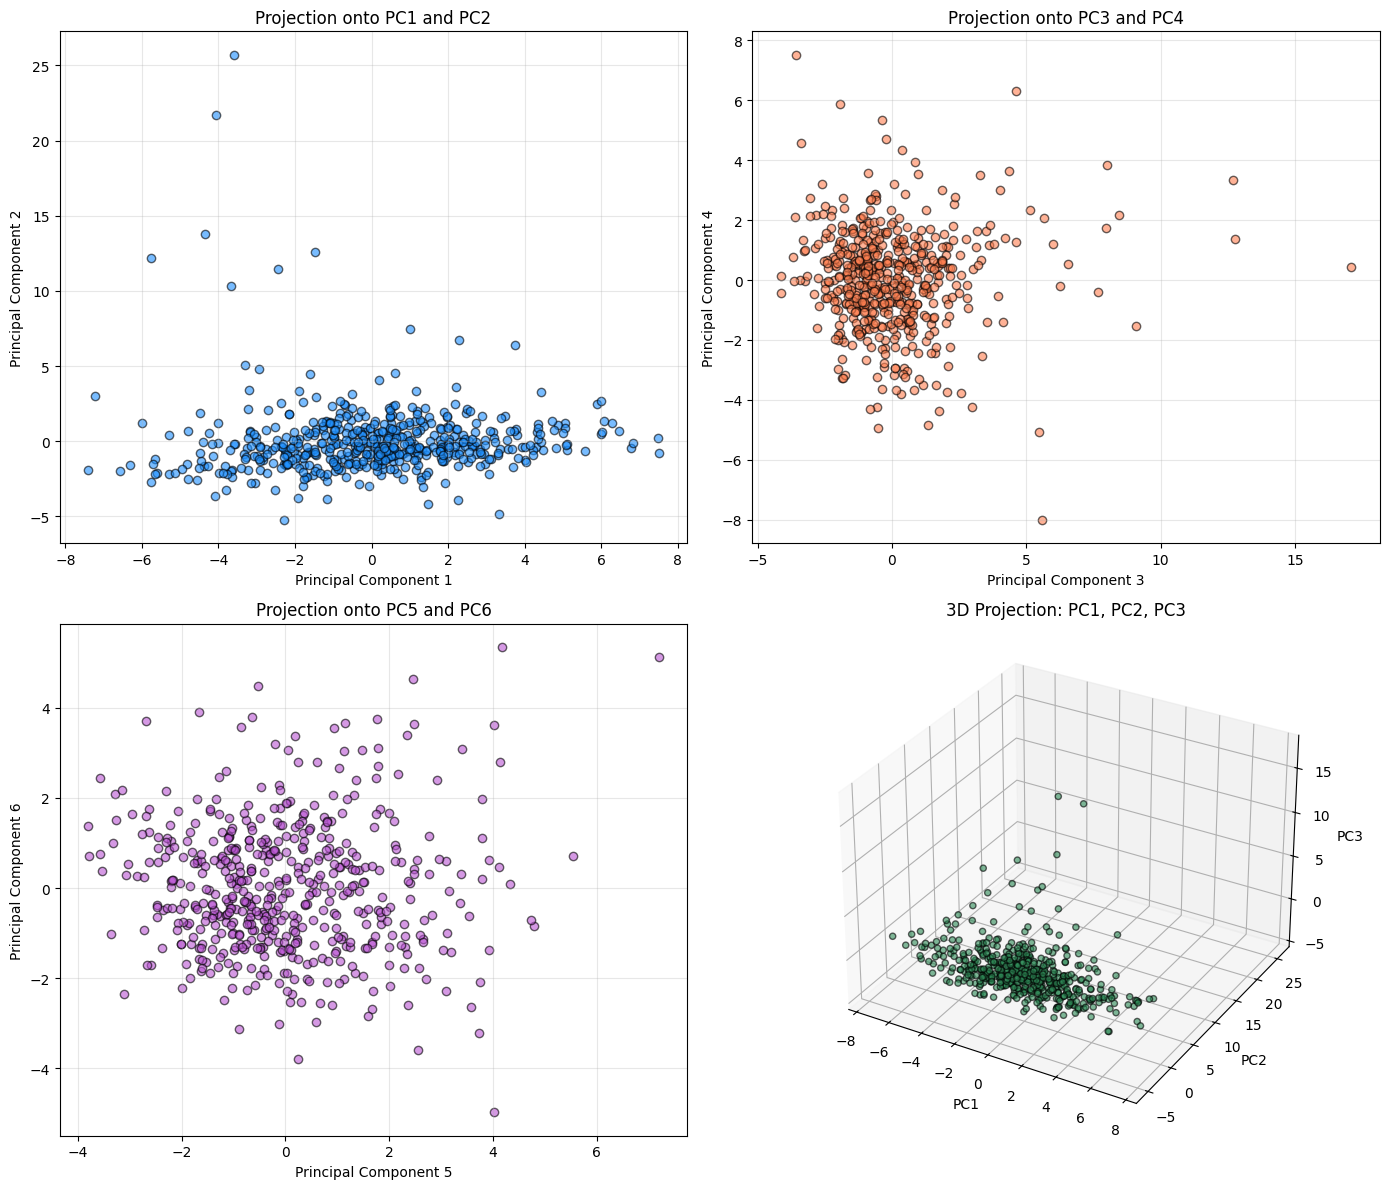

In [6]:
# Create a 2x2 figure grid to hold our subplots
fig = plt.figure(figsize=(14, 12))

# Subset 1: PC1 vs PC2 (2 components)
ax1 = fig.add_subplot(221)
ax1.scatter(df_projected['PC1'], df_projected['PC2'], alpha=0.6, edgecolors='k', color='dodgerblue')
ax1.set_xlabel('Principal Component 1')
ax1.set_ylabel('Principal Component 2')
ax1.set_title('Projection onto PC1 and PC2')
ax1.grid(True, alpha=0.3)

# Subset 2: PC3 vs PC4 (2 components)
ax2 = fig.add_subplot(222)
ax2.scatter(df_projected['PC3'], df_projected['PC4'], alpha=0.6, edgecolors='k', color='coral')
ax2.set_xlabel('Principal Component 3')
ax2.set_ylabel('Principal Component 4')
ax2.set_title('Projection onto PC3 and PC4')
ax2.grid(True, alpha=0.3)

# Subset 3: PC5 vs PC6 (2 components)
ax3 = fig.add_subplot(223)
ax3.scatter(df_projected['PC5'], df_projected['PC6'], alpha=0.6, edgecolors='k', color='mediumorchid')
ax3.set_xlabel('Principal Component 5')
ax3.set_ylabel('Principal Component 6')
ax3.set_title('Projection onto PC5 and PC6')
ax3.grid(True, alpha=0.3)

# Subset 4: PC1, PC2, PC3 (3 components)
ax4 = fig.add_subplot(224, projection='3d')
ax4.scatter(df_projected['PC1'], df_projected['PC2'], df_projected['PC3'], alpha=0.6, edgecolors='k', color='seagreen')
ax4.set_xlabel('PC1')
ax4.set_ylabel('PC2')
ax4.set_zlabel('PC3')
ax4.set_title('3D Projection: PC1, PC2, PC3')

plt.tight_layout()
plt.show()

### Discussion on Projections

**Projection onto PC1 and PC2:**
The scatter plot reveals a highly concentrated central cluster near the origin, representing standard operational days at the water treatment plant. However, there are extreme outliers extending vertically along the PC2 axis (reaching values over 25) and spreading moderately along the PC1 axis. This indicates that the largest variances in the dataset are driven by a small number of days with massive anomalous readings.

**Projection onto PC3 and PC4:**
This subset captures secondary systemic variances. The data is more diffusely spread compared to the dense core of the first plot. While there are a few notable deviations (such as a point extending past 15 on PC3 and points reaching $\pm 8$ on PC4), it lacks the extreme, singular directional magnitude seen in PC2.

**Projection onto PC5 and PC6:**
As these components correspond to the eigenvalues closest to the noise edge, the projection forms a more spherical, Gaussian-like distribution mostly bounded between -4 and 4 on both axes. The physical phenomena captured here are subtle, lacking the distinct structural arms and separating outliers seen in the earlier principal components.

**3D Projection (PC1, PC2, PC3):**
The 3D view effectively illustrates the geometry of the dominant data subspace. It clearly shows the central "normal" data cloud sitting at the base, with the major operational deviations forming a stark, distinct spike extending upward primarily along the PC2 dimension.

## Analyze and Interpret

The dimension-reduced data provides a clear descriptive picture of the Water Treatment Plant's operations: the facility maintains a highly stable baseline (represented by the dense central cluster in all projections) scattered by rare, extreme anomalous events.

* **Statistical Significance of Outliers:** The extreme points projecting far along the PC1 and PC2 axes are entirely separated from the central cluster. The largest outliers are usually statistically significant. In the context of wastewater treatment, these components cleanly isolate severe operational disruptions, such as a massive influx of a specific pollutant or a major multi-sensor equipment failure, from everyday background noise.
  
* **Strong Correlations:** Because this dataset consists of multiple sensors reading from the same connected water processing stages, the underlying physical features are likely heavily correlated. When dealing with strong correlations, the Marčenko-Pastur fit may be poor. While high correlations can shift the empirical bulk slightly, the primary outliers I isolated are of such a large magnitude that their mathematical and structural significance remains completely robust.

* **Sparse Data Considerations:** While this dataset is not strictly sparse in the traditional sense, sensor dropouts or missing daily logs can mimic sparsity. When dealing with sparse data, many noise-induced outliers may appear. Since I imputed missing values using column means in Step 1, days with an exceptionally high number of missing features could theoretically be pushed away from the origin. To finalize the analysis in a real-world scenario, one would cross-reference the index of the extreme PC2 outliers with the raw data to ensure they represent true chemical anomalies rather than extreme instances of missing data. 

In [7]:
!pip install nbconvert 
!jupyter nbconvert --to html "Anthony_Mitine_MATH182_PCA_of_Water_Treatment_Plant_Data.ipynb"

[NbConvertApp] Converting notebook Anthony_Mitine_MATH182_PCA_of_Water_Treatment_Plant_Data.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 2 image(s).
[NbConvertApp] Writing 797862 bytes to Anthony_Mitine_MATH182_PCA_of_Water_Treatment_Plant_Data.html
